# California Property Close Price Prediction — Exploratory Data Analysis

## Objective
Explore CRMLS sold-property data to understand the dataset structure,
data quality, target variable, and potential features for predicting ClosePrice.

### Initial Data Quality Findings

- 5 properties have non-positive LivingArea.
- 4 properties report 0 bathrooms.
- 11 properties report 0 bedrooms.
- No non-positive ClosePrice values were identified.
- No duplicate rows or duplicate ListingKeys were identified.
- 1 property has a CloseDate earlier than its ListingContractDate.
- Suspicious values are flagged for later preprocessing rather than automatically removed during EDA.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
     
oct_2025

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.00,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.00,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23228,SierraNorthValley,SierraNorthValley,NaN,NaN,NaN,NaN,NaN,2988.9,1031966319,mike@cbcnorcal.com,...,NaN,1.98,NaN,NaN,NaN,NaN,95973,NaN,86248.8,NaN
23229,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,49950.0,1024124635,homes@nemechek.com,...,NaN,3784.00,NaN,NaN,NaN,Other,95033,32.0,3784.0,NaN
23230,Southland,Southland,NaN,True,NaN,NaN,NaN,27500.0,1019938353,karmen@bigvalleyrealestate.com,...,NaN,9.79,NaN,False,NaN,NaN,93535,0.0,426452.4,NaN
23231,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,True,NaN,NaN,NaN,405000.0,1016333779,cavanaughcustompropertybrokers@gmail.com,...,NaN,4.34,NaN,NaN,NaN,NaN,92084,0.0,189050.4,NaN


In [88]:
oct_2025.shape

(23233, 78)

In [89]:
oct_2025.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [90]:
oct_2025_residential = oct_2025[oct_2025['PropertyType']== 'Residential']
oct_2025_residential_single =  oct_2025_residential[oct_2025_residential['PropertySubType']== 'SingleFamilyResidence']
oct_2025_residential_single

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN
5,SanDiego,SanDiego,NaN,False,NaN,NaN,False,575000.0,1145277224,garylawrence@kw.com,...,NaN,NaN,NaN,False,2.0,NaN,91945,NaN,NaN,NaN
7,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1243810.0,1145272633,taylor@acme-re.com,...,NaN,2066.00,NaN,True,NaN,NaN,90065,141.25,2066.0,NaN
8,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1227060.0,1145272243,taylor@acme-re.com,...,NaN,1804.00,NaN,True,NaN,NaN,90065,141.25,1804.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23205,PacificWest,PacificWest,Tile,True,NaN,NaN,False,1100000.0,1041258160,TRAN2TRAN@aol.com,...,NaN,1400.00,1.0,False,0.0,Huntington Beach Union High,92648,0.00,1400.0,NaN
23206,SierraNorthValley,SierraNorthValley,"Laminate,SeeRemarks",True,NaN,NaN,False,355000.0,1041228703,mrgchico@sbcglobal.net,...,NaN,7600.00,3.0,False,0.0,Corning Union,96021,0.00,7600.0,NaN
23207,CitrusValley,CitrusValley,NaN,True,NaN,NaN,False,520000.0,1041127058,sarasanchezsellsrealestate@gmail.com,...,NaN,21780.00,2.0,False,0.0,Beaumont,92223,0.00,21780.0,NaN
23222,SanDiego,SanDiego,NaN,False,NaN,NaN,True,75000000.0,1034539730,caren@equestrianre.com,...,NaN,1402.52,NaN,False,4.0,NaN,92003,NaN,61093771.2,NaN


In [91]:
oct_2025_residential_single['PropertyType'].value_counts()
oct_2025_residential_single['PropertySubType'].value_counts()

PropertySubType
SingleFamilyResidence    12029
Name: count, dtype: int64

Note : 11 single-family residence records report BedroomsTotal = 0. The metadata defines BedroomsTotal as the total number of bedrooms in the dwelling but does not specify whether zero can represent missing/unreported information. These records were flagged for further investigation rather than automatically removed.

In [92]:
#data quality check

df_oct25 = oct_2025_residential_single
missing_values = pd.DataFrame({'count' :df_oct25.isna().sum(), 'percent' :df_oct25.isna().mean() * 100 }).sort_values('percent', ascending=False)
missing_values

,count,percent
MiddleOrJuniorSchoolDistrict,12029,100.0
FireplacesTotal,12029,100.0
AboveGradeFinishedArea,12029,100.0
TaxAnnualAmount,12029,100.0
TaxYear,12029,100.0
...,...,...
StateOrProvince,0,0.0
City,0,0.0
ListAgentLastName,0,0.0
ListingContractDate,0,0.0


In [93]:
below_zero_living_area = (df_oct25['LivingArea'] <= 0).sum()
below_zero_living_area

np.int64(5)

In [94]:
below_zero_close_price =(df_oct25['ClosePrice'] <= 0).sum()
below_zero_close_price



np.int64(0)

In [95]:
#No negative values , only zeros
zero_bathrooms =(df_oct25['BathroomsTotalInteger'] <= 0).sum()
zero_bathrooms




np.int64(4)

In [96]:
#No negative values, only zeros
zero_bedrooms =(df_oct25['BedroomsTotal'] <= 0).sum()
zero_bedrooms

np.int64(11)

In [97]:
#How many values have the CloseDate before the ListingContractDate
close_before_list = (df_oct25['CloseDate'] < df_oct25['ListingContractDate']).sum()
close_before_list

np.int64(1)

In [98]:
#What value has the CloseDate before the ListingContractDate
close_before_list_value = df_oct25[(df_oct25['CloseDate'] < df_oct25['ListingContractDate'])]
close_before_list_value

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
15,SanDiego,SanDiego,NaN,True,NaN,NaN,False,4750000.0,1145255773,jan@janclements.com,...,NaN,NaN,NaN,False,2.0,NaN,92118,NaN,NaN,NaN


In [99]:
#checking for duplicates

df_oct25.duplicated().sum()

np.int64(0)

In [100]:
duplicate_keys = df_oct25[df_oct25.duplicated(subset=['ListingKey'])]
duplicate_keys 


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict


In [101]:
zero_bedrooms = df_oct25[df_oct25['BedroomsTotal'] == 0]

zero_bedrooms[['BedroomsTotal','BathroomsTotalInteger','LivingArea','ClosePrice','PropertySubType','City','PostalCode']]

,BedroomsTotal,BathroomsTotalInteger,LivingArea,ClosePrice,PropertySubType,City,PostalCode
1037,0.0,2.0,1594.0,1400000.0,SingleFamilyResidence,San Francisco,94127
6310,0.0,0.0,414.0,150000.0,SingleFamilyResidence,Berkeley,94704
8308,0.0,1.0,404.0,499000.0,SingleFamilyResidence,Fort Bragg,95437
8375,0.0,2.0,2160.0,70000.0,SingleFamilyResidence,Barstow,92311
14957,0.0,1.0,3520.0,500000.0,SingleFamilyResidence,Aguanga,92536
18268,0.0,1.0,400.0,480000.0,SingleFamilyResidence,Santa Ana,92703
20503,0.0,0.0,0.0,876838.0,SingleFamilyResidence,Bakersfield,93311
21800,0.0,1.0,624.0,80000.0,SingleFamilyResidence,Onyx,93255
22181,0.0,0.0,0.0,678821.0,SingleFamilyResidence,Palm Desert,92211
22958,0.0,1.0,639.0,150000.0,SingleFamilyResidence,Yucca Valley,92284


In [102]:
zero_bathrooms = df_oct25[df_oct25['BathroomsTotalInteger'] == 0]

zero_bathrooms[['BedroomsTotal','BathroomsTotalInteger','LivingArea','ClosePrice','PropertySubType','City','PostalCode']]

,BedroomsTotal,BathroomsTotalInteger,LivingArea,ClosePrice,PropertySubType,City,PostalCode
6310,0.0,0.0,414.0,150000.0,SingleFamilyResidence,Berkeley,94704
20503,0.0,0.0,0.0,876838.0,SingleFamilyResidence,Bakersfield,93311
22181,0.0,0.0,0.0,678821.0,SingleFamilyResidence,Palm Desert,92211
23042,0.0,0.0,196.0,49900.0,SingleFamilyResidence,29 Palms,92277


An extreme ClosePrice observation of $989.5M was identified for a 2,289 sq-ft property in Valencia (~$432K/sq-ft). This observation is substantially more extreme than other high-priced properties and was flagged for later outlier treatment.

In [103]:
# Looking at ClosePrice
df_oct25['ClosePrice'].describe()

count    1.202900e+04
mean     1.333730e+06
std      9.138420e+06
min      4.850000e+02
25%      6.300000e+05
50%      8.881630e+05
75%      1.400000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

In [104]:
df_oct25['ClosePrice'].nlargest(10)
largest_close_price = df_oct25.nlargest(10, 'ClosePrice')[['ClosePrice', 'LivingArea', 'BedroomsTotal','BathroomsTotalInteger', 'City', 'PostalCode']]
largest_close_price


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,City,PostalCode
5842,989500000.0,2289.0,5.0,3.0,Valencia,91355
23222,53000000.0,7865.0,3.0,5.0,Bonsall,92003
22931,49999999.0,6003.0,7.0,9.0,Del Mar,92014
3938,38000000.0,11494.0,5.0,11.0,Newport Coast,92657
20670,34000000.0,12664.0,9.0,13.0,Beverly Hills,90210
23040,32000000.0,15355.0,9.0,14.0,Santa Barbara,93108
22932,26055000.0,11900.0,6.0,8.0,Los Angeles,90069
9063,23700000.0,1428.0,3.0,2.0,Santa Barbara,93111
13858,23000000.0,9000.0,7.0,7.0,Los Angeles,90049
14,22610000.0,9220.0,6.0,8.0,Pacific Palisades,90272


In [105]:
#price per sqft of the largest close prices from the above cell
largest_close_price['PricePerSqFt'] = largest_close_price['ClosePrice']/largest_close_price['LivingArea']
largest_close_price


,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,City,PostalCode,PricePerSqFt
5842,989500000.0,2289.0,5.0,3.0,Valencia,91355,432284.840542
23222,53000000.0,7865.0,3.0,5.0,Bonsall,92003,6738.715830
22931,49999999.0,6003.0,7.0,9.0,Del Mar,92014,8329.168582
3938,38000000.0,11494.0,5.0,11.0,Newport Coast,92657,3306.072734
20670,34000000.0,12664.0,9.0,13.0,Beverly Hills,90210,2684.775742
23040,32000000.0,15355.0,9.0,14.0,Santa Barbara,93108,2084.011723
22932,26055000.0,11900.0,6.0,8.0,Los Angeles,90069,2189.495798
9063,23700000.0,1428.0,3.0,2.0,Santa Barbara,93111,16596.638655
13858,23000000.0,9000.0,7.0,7.0,Los Angeles,90049,2555.555556
14,22610000.0,9220.0,6.0,8.0,Pacific Palisades,90272,2452.277657


In [106]:
#understanding numerical features
df_oct25['LivingArea'].describe()


count    12024.000000
mean      2054.109737
std       1033.515850
min          0.000000
25%       1392.750000
50%       1824.000000
75%       2441.000000
max      16683.000000
Name: LivingArea, dtype: float64

In [107]:
df_oct25['BedroomsTotal'].describe()

count    12029.000000
mean         3.496799
std          0.959139
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         11.000000
Name: BedroomsTotal, dtype: float64

In [108]:
df_oct25['BathroomsTotalInteger'].describe()

count    12029.000000
mean         2.634882
std          1.124832
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: BathroomsTotalInteger, dtype: float64

In [109]:
#The areas where max number of properties are located
top_num_areas = df_oct25['MLSAreaMajor'].value_counts().head(10)
top_num_areas


MLSAreaMajor
699 - Not Defined                       1026
SRCAR - Southwest Riverside County       608
252 - Riverside                          197
LAC - Lancaster                          111
263 - Banning/Beaumont/Cherry Valley     111
248 - Corona                             106
259 - Moreno Valley                       99
VIC - Victorville                         99
274 - San Bernardino                      96
APPV - Apple Valley                       88
Name: count, dtype: int64

Understanding the relationships between certain features and ClosePrice


In [110]:
lower_bound = df_oct25['ClosePrice'].quantile(0.005)
upper_bound = df_oct25['ClosePrice'].quantile(0.995)
plot_df = df_oct25[(df_oct25['ClosePrice'] >= lower_bound) & (df_oct25['ClosePrice'] <= upper_bound)]
plot_df

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN
5,SanDiego,SanDiego,NaN,False,NaN,NaN,False,575000.0,1145277224,garylawrence@kw.com,...,NaN,NaN,NaN,False,2.0,NaN,91945,NaN,NaN,NaN
7,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1243810.0,1145272633,taylor@acme-re.com,...,NaN,2066.0,NaN,True,NaN,NaN,90065,141.25,2066.0,NaN
8,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Tile,True,NaN,NaN,False,1227060.0,1145272243,taylor@acme-re.com,...,NaN,1804.0,NaN,True,NaN,NaN,90065,141.25,1804.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23203,OutOfAreaBoard,OutOfAreaBoard,"Carpet,Tile",True,NaN,NaN,False,3495000.0,1041292018,allan@santaynezvalley.com,...,NaN,856825.0,NaN,False,NaN,NaN,93460,735.00,856825.0,NaN
23205,PacificWest,PacificWest,Tile,True,NaN,NaN,False,1100000.0,1041258160,TRAN2TRAN@aol.com,...,NaN,1400.0,1.0,False,0.0,Huntington Beach Union High,92648,0.00,1400.0,NaN
23206,SierraNorthValley,SierraNorthValley,"Laminate,SeeRemarks",True,NaN,NaN,False,355000.0,1041228703,mrgchico@sbcglobal.net,...,NaN,7600.0,3.0,False,0.0,Corning Union,96021,0.00,7600.0,NaN
23207,CitrusValley,CitrusValley,NaN,True,NaN,NaN,False,520000.0,1041127058,sarasanchezsellsrealestate@gmail.com,...,NaN,21780.0,2.0,False,0.0,Beaumont,92223,0.00,21780.0,NaN


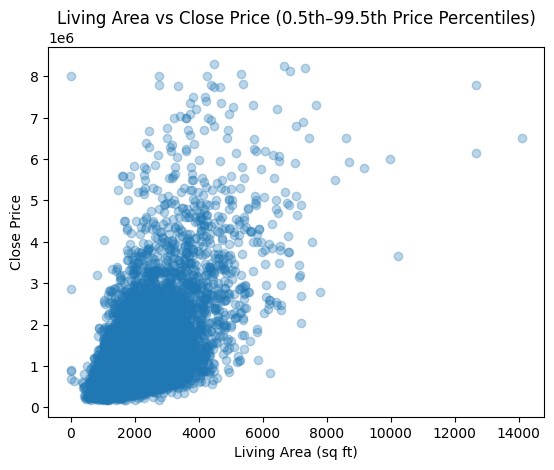

In [111]:
#Close price is in millions
#Living Area vs. Close Price
plt.scatter(plot_df['LivingArea'],plot_df['ClosePrice'],alpha=0.3)
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Close Price')
plt.title('Living Area vs Close Price (0.5th–99.5th Price Percentiles)')
plt.show()

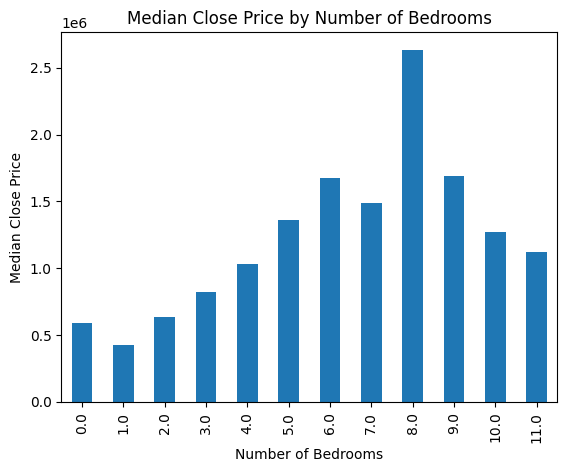

In [112]:
#Close price is in millions
#BedroomsTotal vs. Close Price
median_price_by_bedrooms = (plot_df.groupby('BedroomsTotal')['ClosePrice'].median())

median_price_by_bedrooms.plot(kind='bar')

plt.xlabel('Number of Bedrooms')
plt.ylabel('Median Close Price')
plt.title('Median Close Price by Number of Bedrooms')
plt.show()